# Detailed Debug Notebook: Short RNA Prediction

This notebook allows step-by-step inspection of the short RNA prediction pipeline for a specific transcript:
- Initial MMD score
- Window scanning: MMD scores at each position
- Perturbation analysis: how end-position shifts affect MMD
- Final prediction and why it was chosen
- Potential local vs global minima detection

**Use this to investigate:**
- Why a prediction has a particular score
- Whether the algorithm is stuck in a local minimum
- How the embedding cloud looks at each step

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# --- CONFIGURATION: Edit these paths ---
repo_root = Path("/Users/Bogdan.Kirilenko/Developer/CURIA_pipeline")
pyrion_path = repo_root.parent / "pyrion"  # adjust if needed

# Add module paths
sys.path.insert(0, str(repo_root / "modules" / "utils"))
sys.path.insert(0, str(repo_root / "modules" / "RNA-FM"))
sys.path.insert(0, str(repo_root / "modules" / "pipeline"))
sys.path.insert(0, str(pyrion_path))

import short_ncrna as sn
import fm
from pyrion import TwoBitAccessor
import pyrion

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

In [2]:
# --- INPUT: Specify the transcript to debug ---
# You can copy a line from short_ncRNA_joblist.txt
# Format: transcript_id\tchain_id\tbiotype\ttranscript_region\ttranscript_strand\tquery_region\tquery_strand

transcript_id_to_debug = "U_ENSG00000207758"  # <-- CHANGE THIS

# Alternatively, paste a full job line:
job_line = None  # e.g., "U_ENSG00000278278.1\t186\tmiRNA\tchr22:20114685-20114751\t-1\tchr16:18069188-18069491\t1"

# --- Paths to data ---
PIPELINE_DIR = repo_root / "quick_test"
ANNOTATION_DIR = repo_root / "input_data" / "mm39_annotation_validation"

joblist_path = PIPELINE_DIR / "joblists" / "short_ncRNA_joblist.txt"
union_bed_path = PIPELINE_DIR / "union_transcripts.bed"
ref_2bit_path = repo_root / "input_data" / "2bit" / "hg38.2bit"
query_2bit_path = repo_root / "input_data" / "2bit" / "mm39.2bit"

# --- Prediction parameters (match pipeline defaults) ---
flank_ratio = 0.1
min_length_ratio = 0.8
max_length_ratio = 1.2
window_step = 1
perturbation_range = 5
max_batch = 128

In [3]:
# Load the job for the specified transcript
if job_line is not None:
    parts = job_line.strip().split("\t")
    job = sn.ShortRNAJob(
        transcript_id=parts[0],
        chain_id=parts[1],
        biotype=parts[2],
        transcript_region=parts[3],
        transcript_strand=int(parts[4]),
        query_region=parts[5],
        query_strand=int(parts[6]),
    )
else:
    # Find the job by transcript_id
    job = None
    with open(joblist_path, "r") as f:
        header = f.readline().strip().split("\t")
        for line in f:
            parts = line.strip().split("\t")
            if parts[0] == transcript_id_to_debug:
                job = sn.ShortRNAJob(
                    transcript_id=parts[0],
                    chain_id=parts[1],
                    biotype=parts[2],
                    transcript_region=parts[3],
                    transcript_strand=int(parts[4]),
                    query_region=parts[5],
                    query_strand=int(parts[6]),
                )
                break
    
    if job is None:
        raise ValueError(f"Transcript {transcript_id_to_debug} not found in joblist")

print("=" * 80)
print(f"DEBUGGING TRANSCRIPT: {job.transcript_id}")
print("=" * 80)
print(f"Chain ID:          {job.chain_id}")
print(f"Biotype:           {job.biotype}")
print(f"Ref region:        {job.transcript_region} (strand {job.transcript_strand})")
print(f"Query region:      {job.query_region} (strand {job.query_strand})")
print()

DEBUGGING TRANSCRIPT: U_ENSG00000207758
Chain ID:          26
Biotype:           miRNA
Ref region:        chrX:50003147-50003238 (strand 1)
Query region:      chrX:7114644-7114735 (strand -1)



In [4]:
# Load transcripts and extract sequences
transcripts = pyrion.io.read_bed12_file(str(union_bed_path))
transcripts_by_id = {t.id: t for t in transcripts}

t = transcripts_by_id.get(job.transcript_id)
if t is None:
    raise ValueError(f"Transcript not found in {union_bed_path}: {job.transcript_id}")

ref_accessor = TwoBitAccessor(str(ref_2bit_path))
query_accessor = TwoBitAccessor(str(query_2bit_path))

ref_seq = sn._get_spliced_sequence(t, ref_accessor)
ref_length = len(ref_seq)

print(f"Reference sequence length: {ref_length} nt")
print(f"Reference sequence: {ref_seq[:100]}{'...' if len(ref_seq) > 100 else ''}")
print()

Reference sequence length: 91 nt
Reference sequence: CGACUUGCUUUCUCUCCUCCAUGCCUUGAGUGUAGGACCGUUGGCAUCUUAAUUACCCUCCCACACCCAAGGCUUGCAGAAGAGCGAGCCU



In [5]:
# Extract and extend query sequence
q_chrom, q_start, q_end = sn._parse_region(job.query_region)
query_seq = sn._extract_sequence(query_accessor, q_chrom, q_start, q_end, job.query_strand)

extended_query, ext_start, ext_end = sn._add_flanks(
    query_seq,
    q_chrom,
    q_start,
    q_end,
    job.query_strand,
    ref_length,
    query_accessor,
    flank_ratio,
)

print(f"Query region:      {q_chrom}:{q_start}-{q_end} ({len(query_seq)} nt)")
print(f"Extended region:   {q_chrom}:{ext_start}-{ext_end} ({len(extended_query)} nt)")
print(f"Flanks added:      {ext_start - q_start} nt upstream, {ext_end - q_end} nt downstream")
print(f"Extended query:    {extended_query[:100]}{'...' if len(extended_query) > 100 else ''}")
print()

Query region:      chrX:7114644-7114735 (91 nt)
Extended region:   chrX:7114640-7114740 (100 nt)
Flanks added:      -4 nt upstream, 5 nt downstream
Extended query:    CCUACAGAUUUGCUUUUUCUCUUCCAUGCCUUGAGUGUAGGACCGUUGACAUCUUAAUUACCCUCCCACACCCAAGGCUUGCAGGAGAGCAAGCCUUCUC



## Load RNA-FM and PCA Projector

In [6]:
class PCAProjector:
    def __init__(self, pca_path: Path, device: torch.device):
        data = np.load(pca_path)
        self.mean = torch.from_numpy(data["mean"]).float().to(device)
        self.components = torch.from_numpy(data["components"]).float().to(device)

    def project(self, x: torch.Tensor) -> torch.Tensor:
        return (x - self.mean) @ self.components.T


def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


device = get_device()
model, alphabet = fm.pretrained.rna_fm_t12()
model.eval().to(device)
batch_converter = alphabet.get_batch_converter()

pca_path = repo_root / "modules" / "global_PCA" / "rnafm_pca_k16.npz"
pca = PCAProjector(pca_path, device)

print(f"Device: {device}")
print(f"RNA-FM model loaded")
print(f"PCA projector loaded ({pca.components.shape[0]} components)")
print()

Device: mps
RNA-FM model loaded
PCA projector loaded (16 components)



In [7]:
# Embedding utilities (token-level, PCA-projected)
def _normalize_sequence(seq: str) -> str:
    return seq.upper().replace("T", "U")


def embed_token_pca(seqs, batch_size=128):
    out = []
    for i in range(0, len(seqs), batch_size):
        chunk = seqs[i:i + batch_size]
        data = [(f"seq_{i+j}", _normalize_sequence(s)) for j, s in enumerate(chunk)]
        _, _, batch_tokens = batch_converter(data)
        batch_tokens = batch_tokens.to(device)
        with torch.no_grad():
            results = model(batch_tokens, repr_layers=[12])
        reps = results["representations"][12]
        token_embeds = []
        for k, seq in enumerate(chunk):
            length = len(seq)
            token_embeds.append(reps[k, 1:1 + length, :])
        concat_tokens = torch.cat(token_embeds, dim=0)
        pca_concat = pca.project(concat_tokens)
        sizes = [t.shape[0] for t in token_embeds]
        splits = torch.split(pca_concat, sizes, dim=0)
        out.extend([s.detach().cpu().numpy() for s in splits])
    return out

## Step 1: Reference Embedding and Initial MMD Context

Reference embedding shape: (91, 16)
Reference MMD context:
  - gamma (RBF bandwidth): 0.041690
  - K_XX_sum: 5289.458984
  - K_XX_trace: 91.000000
  - n_ref: 91



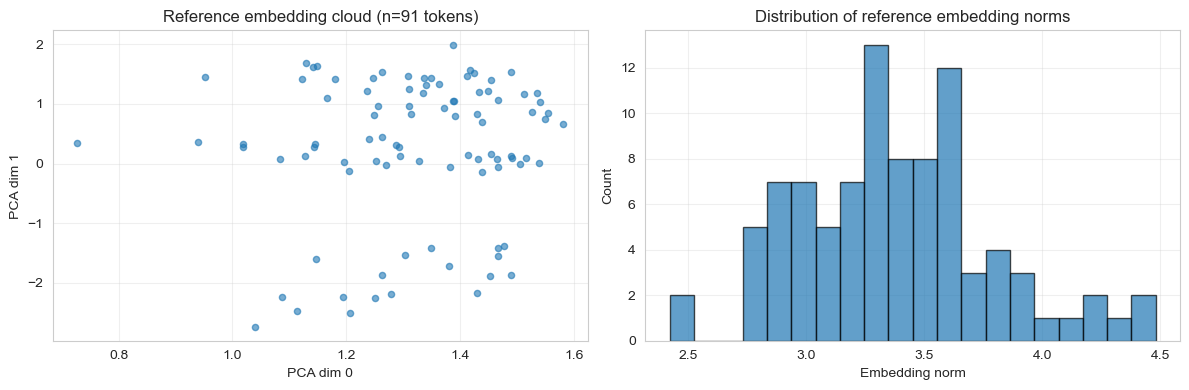

In [8]:
# Compute reference embedding
ref_emb = embed_token_pca([ref_seq], batch_size=1)[0]
ref_ctx = sn._prepare_ref_mmd(ref_emb)
gamma, K_XX_sum, K_XX_trace, n_ref = ref_ctx

print(f"Reference embedding shape: {ref_emb.shape}")
print(f"Reference MMD context:")
print(f"  - gamma (RBF bandwidth): {gamma:.6f}")
print(f"  - K_XX_sum: {K_XX_sum:.6f}")
print(f"  - K_XX_trace: {K_XX_trace:.6f}")
print(f"  - n_ref: {n_ref}")
print()

# Visualize reference embedding cloud
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# PCA of reference embedding (first 2 PCA dimensions)
if ref_emb.shape[1] >= 2:
    axes[0].scatter(ref_emb[:, 0], ref_emb[:, 1], alpha=0.6, s=20)
    axes[0].set_xlabel("PCA dim 0")
    axes[0].set_ylabel("PCA dim 1")
    axes[0].set_title(f"Reference embedding cloud (n={n_ref} tokens)")
    axes[0].grid(True, alpha=0.3)

# Distribution of embedding norms
ref_norms = np.linalg.norm(ref_emb, axis=1)
axes[1].hist(ref_norms, bins=20, alpha=0.7, edgecolor='black')
axes[1].set_xlabel("Embedding norm")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of reference embedding norms")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 2: Window Scanning

Scan all windows across the extended query and compute MMD for each position.

In [9]:
# Scan windows across the extended query
query_len = len(extended_query)
if query_len < ref_length:
    raise ValueError("Extended query is shorter than reference; cannot scan windows")

starts = list(range(0, query_len - ref_length + 1, window_step))
window_seqs = [extended_query[s:s + ref_length] for s in starts]

print(f"Scanning {len(starts)} windows (step={window_step})...")
window_embs = embed_token_pca(window_seqs, batch_size=max_batch)

window_mmd_scores = []
for s, emb in zip(starts, window_embs):
    mmd = sn._compute_mmd_with_ref(ref_ctx, ref_emb, emb)
    window_mmd_scores.append(mmd)

window_df = pd.DataFrame({
    "start": starts,
    "end": [s + ref_length for s in starts],
    "mmd": window_mmd_scores,
})

best_window_idx = window_df["mmd"].idxmin()
best_window_start = window_df.loc[best_window_idx, "start"]
best_window_end = window_df.loc[best_window_idx, "end"]
best_window_mmd = window_df.loc[best_window_idx, "mmd"]

print(f"\nBest window: start={best_window_start}, end={best_window_end}, MMD={best_window_mmd:.6f}")
print(f"\nWindow MMD summary:")
print(window_df["mmd"].describe())
print()

# Show top 10 windows
print("Top 10 windows by MMD:")
print(window_df.nsmallest(10, "mmd"))

Scanning 10 windows (step=1)...

Best window: start=4, end=95, MMD=0.000000

Window MMD summary:
count    10.000000
mean      0.048397
std       0.048916
min       0.000000
25%       0.000000
50%       0.041582
75%       0.083518
max       0.126156
Name: mmd, dtype: float64

Top 10 windows by MMD:
   start  end       mmd
4      4   95  0.000000
5      5   96  0.000000
7      7   98  0.000000
9      9  100  0.000000
6      6   97  0.041016
8      8   99  0.042148
3      3   94  0.081997
2      2   93  0.084025
1      1   92  0.108626
0      0   91  0.126156


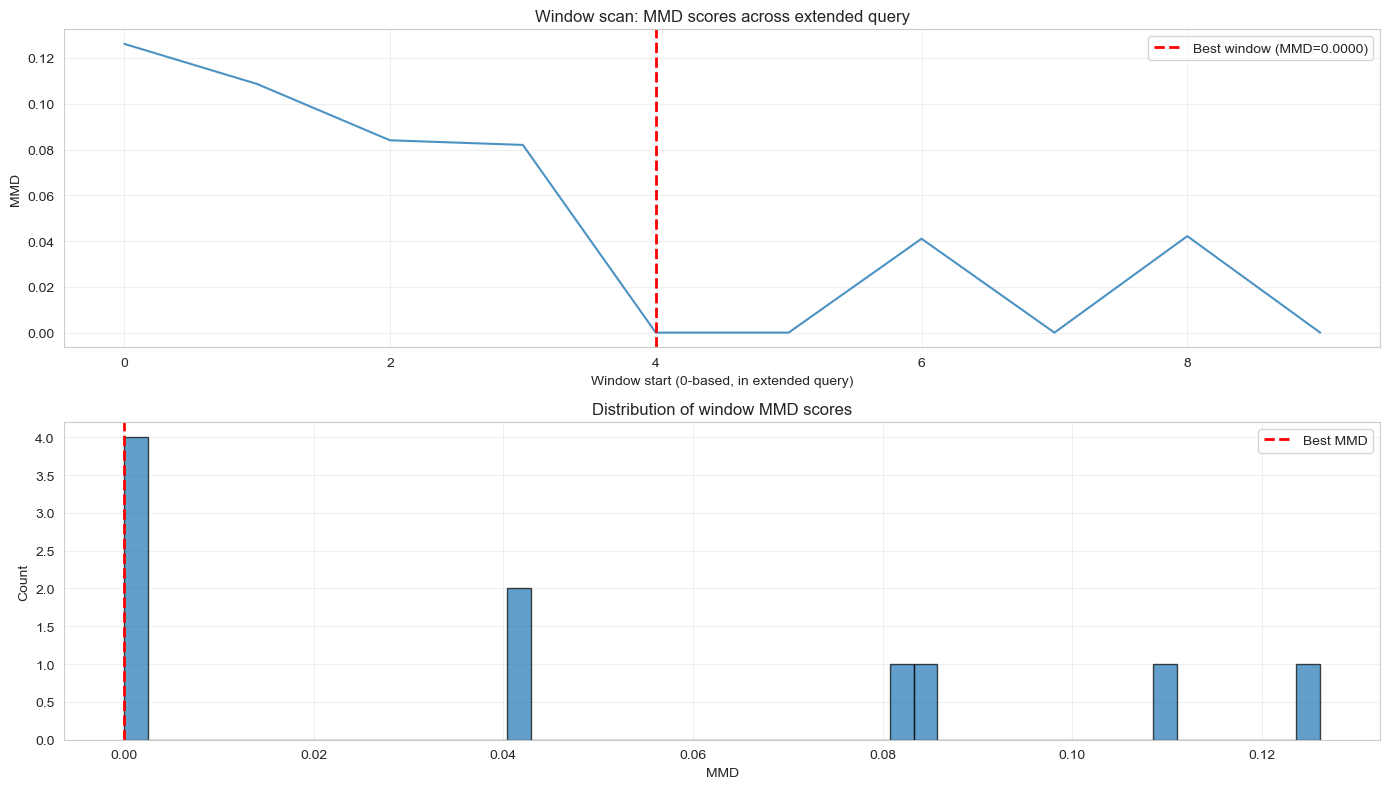


=== LOCAL MINIMA ANALYSIS ===

Top 5 local minima candidates:
  start=   4, end=  95, MMD=0.000000
  start=   5, end=  96, MMD=0.000000
  start=   7, end=  98, MMD=0.000000
  start=   9, end= 100, MMD=0.000000
  start=   6, end=  97, MMD=0.041016

✓ Top minima are close to each other (max gap: 2 nt)


In [10]:
# Visualize window MMD scores
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Full scan
axes[0].plot(window_df["start"], window_df["mmd"], lw=1.5, alpha=0.8)
axes[0].axvline(best_window_start, color="red", linestyle="--", lw=2, label=f"Best window (MMD={best_window_mmd:.4f})")
axes[0].set_xlabel("Window start (0-based, in extended query)")
axes[0].set_ylabel("MMD")
axes[0].set_title("Window scan: MMD scores across extended query")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Histogram of MMD scores
axes[1].hist(window_df["mmd"], bins=50, alpha=0.7, edgecolor='black')
axes[1].axvline(best_window_mmd, color="red", linestyle="--", lw=2, label="Best MMD")
axes[1].set_xlabel("MMD")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of window MMD scores")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Check for potential local minima
print("\n=== LOCAL MINIMA ANALYSIS ===")
sorted_windows = window_df.sort_values("mmd")
top5 = sorted_windows.head(5)
print("\nTop 5 local minima candidates:")
for idx, row in top5.iterrows():
    print(f"  start={int(row['start']):4d}, end={int(row['end']):4d}, MMD={row['mmd']:.6f}")

# Check if there are multiple distinct local minima
top5_starts = top5["start"].values
if len(top5_starts) > 1:
    gaps = np.diff(sorted(top5_starts))
    max_gap = gaps.max() if len(gaps) > 0 else 0
    if max_gap > ref_length:
        print(f"\n⚠️  WARNING: Multiple distinct local minima detected (max gap: {max_gap} nt)")
        print("    The algorithm may have chosen a local minimum instead of the global minimum.")
    else:
        print(f"\n✓ Top minima are close to each other (max gap: {max_gap} nt)")

## Step 3: Perturbation Analysis

Starting from the best window, perturb the end position and refine the prediction.

In [11]:
# Perturb end position around best_window_start
min_len = int(ref_length * min_length_ratio)
max_len = int(ref_length * max_length_ratio)

perturb_records = []
perturb_seqs = []
perturb_metadata = []

for p in range(-perturbation_range, perturbation_range + 1):
    end = int(best_window_end) + p
    if end <= best_window_start or end > query_len:
        continue
    cand_len = end - int(best_window_start)
    if cand_len < min_len or cand_len > max_len:
        continue
    cand_seq = extended_query[int(best_window_start):end]
    perturb_seqs.append(cand_seq)
    perturb_metadata.append((p, end, cand_len))

print(f"Testing {len(perturb_seqs)} perturbations (range={perturbation_range})...")
perturb_embs = embed_token_pca(perturb_seqs, batch_size=max_batch)

for (p, end, cand_len), emb in zip(perturb_metadata, perturb_embs):
    mmd = sn._compute_mmd_with_ref(ref_ctx, ref_emb, emb)
    perturb_records.append({
        "perturbation": p,
        "end": end,
        "length": cand_len,
        "mmd": mmd,
    })

perturb_df = pd.DataFrame(perturb_records).sort_values("mmd")

if perturb_df.empty:
    print("⚠️  No valid perturbation candidates!")
else:
    best_perturb = perturb_df.iloc[0]
    print(f"\nBest perturbation: shift={best_perturb['perturbation']}, end={best_perturb['end']}, length={best_perturb['length']}, MMD={best_perturb['mmd']:.6f}")
    print(f"\nPerturbation MMD summary:")
    print(perturb_df["mmd"].describe())
    print()
    print("All perturbations:")
    print(perturb_df)

Testing 11 perturbations (range=5)...

Best perturbation: shift=-2.0, end=93.0, length=89.0, MMD=0.000000

Perturbation MMD summary:
count    11.000000
mean      0.007179
std       0.014352
min       0.000000
25%       0.000000
50%       0.000000
75%       0.007541
max       0.045330
Name: mmd, dtype: float64

All perturbations:
    perturbation  end  length       mmd
3             -2   93      89  0.000000
4             -1   94      90  0.000000
5              0   95      91  0.000000
6              1   96      92  0.000000
7              2   97      93  0.000000
8              3   98      94  0.000000
9              4   99      95  0.000000
10             5  100      96  0.000000
2             -3   92      88  0.015081
0             -5   90      86  0.018561
1             -4   91      87  0.045330


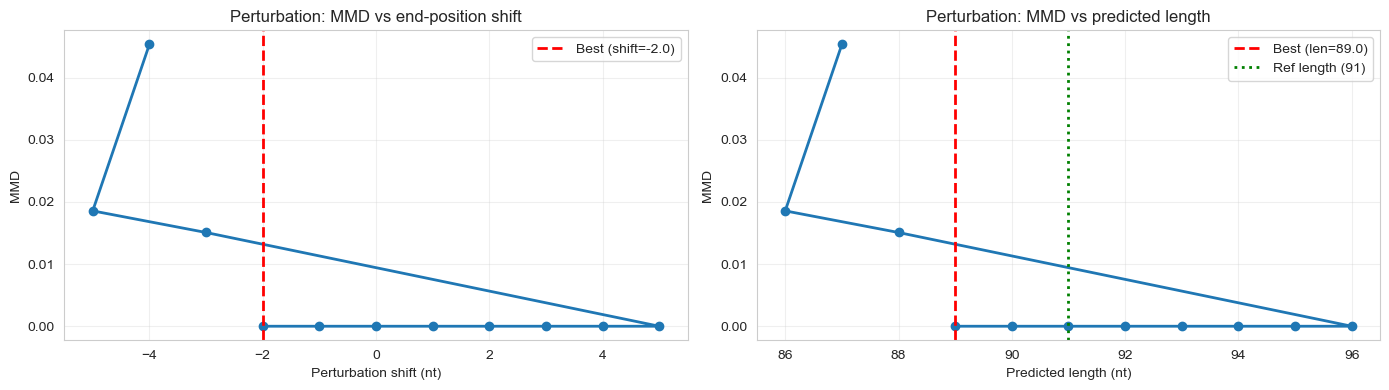

In [12]:
# Visualize perturbation MMD scores
if not perturb_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # MMD vs perturbation shift
    axes[0].plot(perturb_df["perturbation"], perturb_df["mmd"], marker="o", lw=2, markersize=6)
    axes[0].axvline(best_perturb["perturbation"], color="red", linestyle="--", lw=2, label=f"Best (shift={best_perturb['perturbation']})")
    axes[0].set_xlabel("Perturbation shift (nt)")
    axes[0].set_ylabel("MMD")
    axes[0].set_title("Perturbation: MMD vs end-position shift")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # MMD vs predicted length
    axes[1].plot(perturb_df["length"], perturb_df["mmd"], marker="o", lw=2, markersize=6)
    axes[1].axvline(best_perturb["length"], color="red", linestyle="--", lw=2, label=f"Best (len={best_perturb['length']})")
    axes[1].axvline(ref_length, color="green", linestyle=":", lw=2, label=f"Ref length ({ref_length})")
    axes[1].set_xlabel("Predicted length (nt)")
    axes[1].set_ylabel("MMD")
    axes[1].set_title("Perturbation: MMD vs predicted length")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## Step 4: Final Prediction

In [13]:
# Compute final predicted region
if perturb_df.empty:
    print("Cannot compute final prediction: no valid perturbations")
else:
    best_perturb = perturb_df.iloc[0]
    perturb_best_end = int(best_perturb["end"])
    
    if job.query_strand == 1:
        final_start = ext_start + int(best_window_start)
        final_end = ext_start + perturb_best_end
    else:
        final_end = ext_end - int(best_window_start)
        final_start = ext_end - perturb_best_end
    
    final_region = f"{q_chrom}:{final_start}-{final_end}"
    aligned_length = abs(final_end - final_start)
    final_mmd = float(best_perturb["mmd"])
    
    print("=" * 80)
    print("FINAL PREDICTION")
    print("=" * 80)
    print(f"Predicted region:  {final_region}")
    print(f"Aligned length:    {aligned_length} nt (ref: {ref_length} nt)")
    print(f"Final MMD score:   {final_mmd:.6f}")
    print()
    print(f"Original query:    {job.query_region} ({q_end - q_start} nt)")
    print(f"Delta start:       {final_start - q_start:+d} nt")
    print(f"Delta end:         {final_end - q_end:+d} nt")
    print()
    
    # Quality assessment
    print("Quality assessment:")
    if final_mmd == 0.0:
        print("  ✓ Perfect match (MMD = 0.0)")
    elif final_mmd < 0.2:
        print(f"  ✓ Close match (MMD < 0.2)")
    elif final_mmd < 0.5:
        print(f"  ⚠️  Questionable match (0.2 ≤ MMD < 0.5)")
    else:
        print(f"  ❌ Mismatch (MMD ≥ 0.5)")
    
    length_ratio = aligned_length / ref_length
    if 0.95 <= length_ratio <= 1.05:
        print(f"  ✓ Length matches reference ({length_ratio:.2f}x)")
    elif 0.8 <= length_ratio <= 1.2:
        print(f"  ⚠️  Length differs from reference ({length_ratio:.2f}x)")
    else:
        print(f"  ❌ Length very different from reference ({length_ratio:.2f}x)")

FINAL PREDICTION
Predicted region:  chrX:7114647-7114736
Aligned length:    89 nt (ref: 91 nt)
Final MMD score:   0.000000

Original query:    chrX:7114644-7114735 (91 nt)
Delta start:       +3 nt
Delta end:         +1 nt

Quality assessment:
  ✓ Perfect match (MMD = 0.0)
  ✓ Length matches reference (0.98x)


## Step 5: Compare Embeddings

Visualize how the reference, best window, and final prediction embeddings compare.

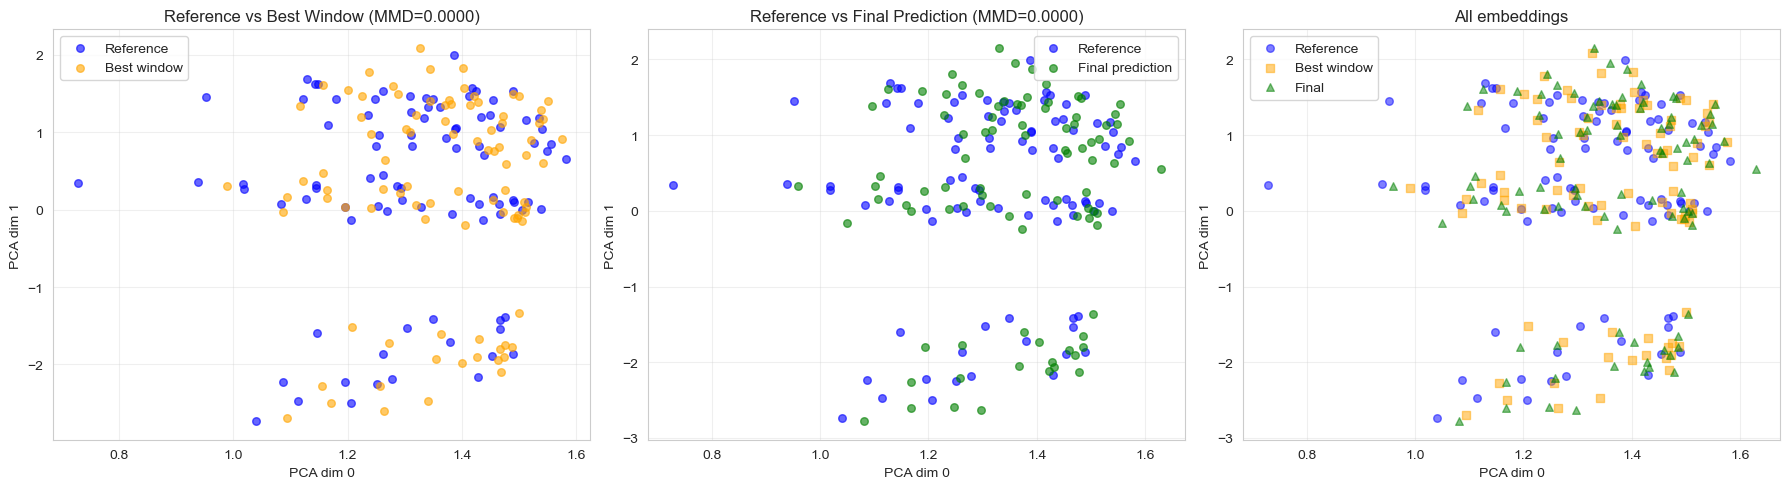

In [14]:
# Get embeddings for best window and final prediction
best_window_seq = extended_query[int(best_window_start):int(best_window_end)]
best_window_emb = embed_token_pca([best_window_seq], batch_size=1)[0]

if not perturb_df.empty:
    final_seq = extended_query[int(best_window_start):int(best_perturb["end"])]
    final_emb = embed_token_pca([final_seq], batch_size=1)[0]
    
    # Visualize embedding clouds
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Reference vs best window
    axes[0].scatter(ref_emb[:, 0], ref_emb[:, 1], alpha=0.6, s=30, label="Reference", color="blue")
    axes[0].scatter(best_window_emb[:, 0], best_window_emb[:, 1], alpha=0.6, s=30, label="Best window", color="orange")
    axes[0].set_xlabel("PCA dim 0")
    axes[0].set_ylabel("PCA dim 1")
    axes[0].set_title(f"Reference vs Best Window (MMD={best_window_mmd:.4f})")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Reference vs final prediction
    axes[1].scatter(ref_emb[:, 0], ref_emb[:, 1], alpha=0.6, s=30, label="Reference", color="blue")
    axes[1].scatter(final_emb[:, 0], final_emb[:, 1], alpha=0.6, s=30, label="Final prediction", color="green")
    axes[1].set_xlabel("PCA dim 0")
    axes[1].set_ylabel("PCA dim 1")
    axes[1].set_title(f"Reference vs Final Prediction (MMD={final_mmd:.4f})")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # All three overlaid
    axes[2].scatter(ref_emb[:, 0], ref_emb[:, 1], alpha=0.5, s=30, label="Reference", color="blue")
    axes[2].scatter(best_window_emb[:, 0], best_window_emb[:, 1], alpha=0.5, s=30, label="Best window", color="orange", marker="s")
    axes[2].scatter(final_emb[:, 0], final_emb[:, 1], alpha=0.5, s=30, label="Final", color="green", marker="^")
    axes[2].set_xlabel("PCA dim 0")
    axes[2].set_ylabel("PCA dim 1")
    axes[2].set_title("All embeddings")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## Summary

This notebook provides a detailed view of:
1. **Initial MMD context**: How the reference embedding looks
2. **Window scanning**: All MMD scores across the extended query
3. **Local vs global minima**: Whether multiple distinct minima exist
4. **Perturbation refinement**: How shifting the end position affects MMD
5. **Final prediction**: The chosen region and quality metrics
6. **Embedding comparison**: Visual comparison of embedding clouds

Use this to:
- Understand why a particular prediction was made
- Detect if the algorithm got stuck in a local minimum
- Tune hyperparameters (window_step, perturbation_range, etc.)
- Investigate false positives/negatives

## Extended Analysis: Larger Flanks and Start Perturbations

**Hypothesis**: The algorithm may be stuck in a local minimum. Let's try:
1. **Larger flanks** (100nt instead of 10%) to capture shifted orthologs
2. **Start position perturbations** to explore the gradient landscape
3. **Broader window scanning** to find global minima

This is especially useful when the true ortholog is shifted relative to the chain-lifted region.

In [15]:
# Add 100nt flanks on each side
flank_size = 100

large_ext_start = max(0, q_start - flank_size)
large_ext_end = q_end + flank_size

large_extended_query = sn._extract_sequence(query_accessor, q_chrom, large_ext_start, large_ext_end, job.query_strand)
large_query_len = len(large_extended_query)

print(f"=== LARGE FLANKS ANALYSIS ===")
print(f"Original query:      {q_chrom}:{q_start}-{q_end} ({q_end - q_start} nt)")
print(f"Large extended:      {q_chrom}:{large_ext_start}-{large_ext_end} ({large_query_len} nt)")
print(f"Flanks:              {q_start - large_ext_start} nt upstream, {large_ext_end - q_end} nt downstream")
print()

=== LARGE FLANKS ANALYSIS ===
Original query:      chrX:7114644-7114735 (91 nt)
Large extended:      chrX:7114544-7114835 (291 nt)
Flanks:              100 nt upstream, 100 nt downstream



In [16]:
# Scan with larger flanks - broader window range
large_starts = list(range(0, large_query_len - ref_length + 1, window_step))
large_window_seqs = [large_extended_query[s:s + ref_length] for s in large_starts]

print(f"Scanning {len(large_starts)} windows with large flanks (this may take longer)...")
large_window_embs = embed_token_pca(large_window_seqs, batch_size=max_batch)

large_window_mmd_scores = []
for s, emb in zip(large_starts, large_window_embs):
    mmd = sn._compute_mmd_with_ref(ref_ctx, ref_emb, emb)
    large_window_mmd_scores.append(mmd)

large_window_df = pd.DataFrame({
    "start": large_starts,
    "end": [s + ref_length for s in large_starts],
    "mmd": large_window_mmd_scores,
})

large_best_idx = large_window_df["mmd"].idxmin()
large_best_start = large_window_df.loc[large_best_idx, "start"]
large_best_end = large_window_df.loc[large_best_idx, "end"]
large_best_mmd = large_window_df.loc[large_best_idx, "mmd"]

print(f"\nBest window (large flanks): start={large_best_start}, end={large_best_end}, MMD={large_best_mmd:.6f}")
print(f"\nTop 10 windows:")
print(large_window_df.nsmallest(10, "mmd"))

Scanning 201 windows with large flanks (this may take longer)...

Best window (large flanks): start=93, end=184, MMD=0.000000

Top 10 windows:
     start  end       mmd
93      93  184  0.000000
99      99  190  0.000000
100    100  191  0.000000
102    102  193  0.000000
104    104  195  0.000000
105    105  196  0.000000
106    106  197  0.000000
101    101  192  0.041016
103    103  194  0.042148
107    107  198  0.044770
